# Face Recognition using Convolutional Neural Networks (CNN) with the Labeled Faces in the Wild (LFW) Dataset

This notebook demonstrates how to build and train a Convolutional Neural Network (CNN) for face recognition using the Labeled Faces in the Wild (LFW) dataset. We will cover data loading, preprocessing, model building with TensorFlow/Keras, training, evaluation, and making predictions.

## 1. Setup and Library Imports

First, let's install any necessary libraries and import all the required modules. We'll be using TensorFlow/Keras for building the CNN, NumPy for numerical operations, Matplotlib and Seaborn for visualizations, and Scikit-learn for dataset loading and evaluation metrics.

In [1]:
# Install necessary libraries (if not already installed)
!pip install scikit-learn tensorflow matplotlib seaborn numpy

# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

## 2. Load and Explore the LFW Dataset

The Labeled Faces in the Wild (LFW) dataset is a public dataset of face photographs designed for studying the problem of unconstrained face recognition. We will use `sklearn.datasets.fetch_lfw_people()` to load it. For simplicity and to ensure faster training, we will filter for faces with at least 70 images.

In [2]:
# Load the LFW dataset
lfw_people = fetch_lfw_people(min_faces_per_person=70, resize=0.4)

# Extract data and target
X = lfw_people.images
y = lfw_people.target

# Get target names
target_names = lfw_people.target_names
n_samples, h, w = lfw_people.images.shape
n_features = X.shape[1]
n_classes = len(target_names)

print(f"Total dataset size:")
print(f"n_samples: {n_samples}")
print(f"n_features: {n_features}")
print(f"n_classes: {n_classes}")
print(f"Image size: {h}x{w}")
print(f"Number of unique individuals: {n_classes}")
print(f"Individuals in the dataset: {target_names}")

Total dataset size:
n_samples: 1288
n_features: 50
n_classes: 7
Image size: 50x37
Number of unique individuals: 7
Individuals in the dataset: ['Ariel Sharon' 'Colin Powell' 'Donald Rumsfeld' 'George W Bush'
 'Gerhard Schroeder' 'Hugo Chavez' 'Tony Blair']


## 3. Data Preprocessing

Data preprocessing steps include:
1.  **Normalization**: Scaling the pixel values from [0, 255] to [0, 1].
2.  **Reshaping**: Reshaping the images to include a channel dimension (for CNN input).
3.  **Label Encoding**: Converting categorical labels into numerical format, then one-hot encoding them.
4.  **Train/Test Split**: Dividing the dataset into training and testing sets.

In [3]:
# Normalize image data to [0, 1]
X = X / 255.0

# Reshape data for CNN input: (n_samples, height, width, channels)
# LFW images are grayscale, so channels = 1
X = X.reshape(n_samples, h, w, 1)

print(f"Shape of normalized and reshaped data X: {X.shape}")

Shape of normalized and reshaped data X: (1288, 50, 37, 1)


In [4]:
# Encode labels
# First convert integer labels to one-hot encoded vectors
y_encoded = to_categorical(y, num_classes=n_classes)

print(f"Shape of one-hot encoded labels y: {y_encoded.shape}")

Shape of one-hot encoded labels y: (1288, 7)


In [5]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.25, random_state=42, stratify=y
)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (966, 50, 37, 1)
Shape of X_test: (322, 50, 37, 1)
Shape of y_train: (966, 7)
Shape of y_test: (322, 7)


## 4. Visualize Sample Images and Class Distribution

It's always good practice to visualize some sample images to ensure the data is loaded correctly. We will also check the distribution of classes to see if the dataset is balanced.

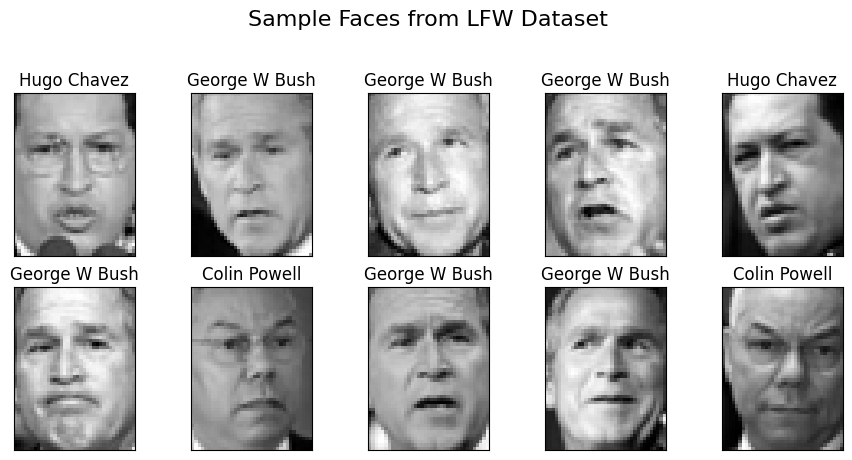

In [6]:
# Function to plot sample images
def plot_sample_images(images, labels, n_row=2, n_col=5, title="Sample Faces"):
    plt.figure(figsize=(1.8 * n_col, 2.4 * n_row))
    plt.suptitle(title, size=16)
    for i in range(n_row * n_col):
        plt.subplot(n_row, n_col, i + 1)
        plt.imshow(images[i].reshape((h, w)), cmap='gray')
        plt.title(target_names[np.argmax(labels[i])], size=12)
        plt.xticks(())
        plt.yticks(())
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Plot sample images from the training set
plot_sample_images(X_train, y_train, title="Sample Faces from LFW Dataset")

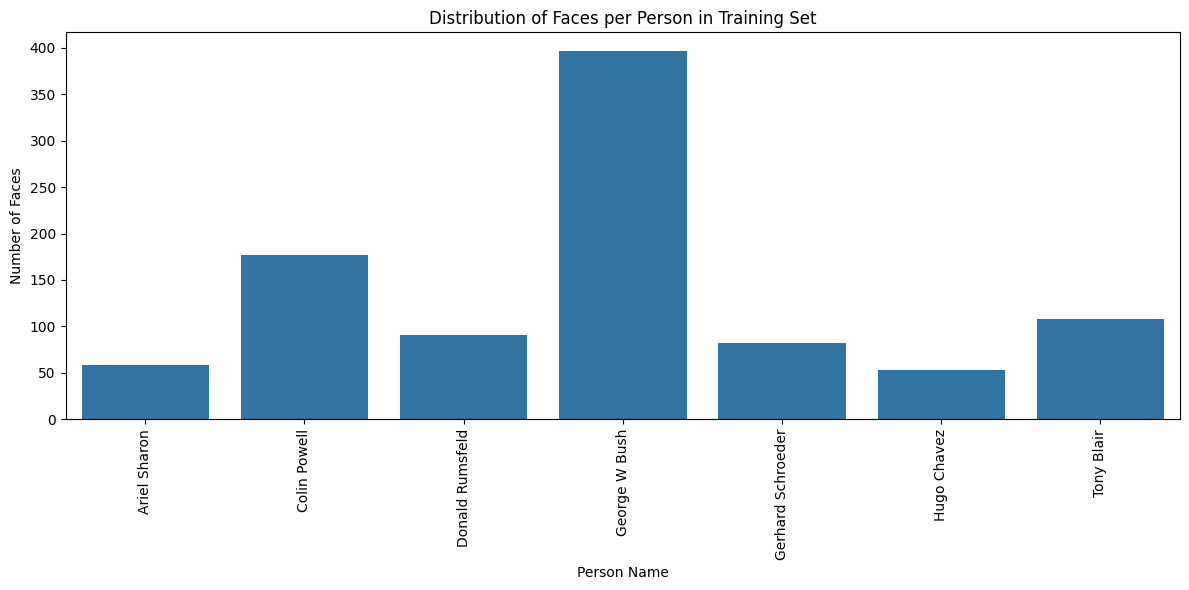

In [7]:
# Plot class distribution
# Need to decode y_train back to original labels for counting
y_train_decoded = np.argmax(y_train, axis=1)
class_counts = np.bincount(y_train_decoded)

plt.figure(figsize=(12, 6))
sns.barplot(x=target_names, y=class_counts)
plt.title('Distribution of Faces per Person in Training Set')
plt.xlabel('Person Name')
plt.ylabel('Number of Faces')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## 5. Building the CNN Model

We will construct a CNN model using `tf.keras.Sequential` API. The model will include:
-   `Conv2D` layers for feature extraction.
-   `MaxPooling2D` layers for down-sampling.
-   `BatchNormalization` for stabilizing training.
-   `Dropout` layers for regularization to prevent overfitting.
-   `Flatten` layer to convert 2D feature maps to 1D vector.
-   `Dense` layers for classification.

In [8]:
# Define the CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(h, w, 1)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Flatten(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(n_classes, activation='softmax') # Output layer with n_classes neurons for classification
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 35, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 35, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 17, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 17, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 22, 15, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 22, 15, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 11, 7, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 11, 7, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 9, 5, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 9, 5, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 358,791 (1.37 MB)

 Trainable params: 357,831 (1.37 MB)

 Non-trainable params: 960 (3.75 KB)

## 6. Compiling and Training the Model

We will compile the model using the Adam optimizer and categorical cross-entropy loss, as it's a multi-class classification problem with one-hot encoded labels. We'll use `EarlyStopping` to prevent overfitting by monitoring the validation loss and stopping training if it doesn't improve after a certain number of epochs.

In [9]:
# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [10]:
# Define EarlyStopping callback
early_stopping = EarlyStopping(
    monitor='val_loss', # Monitor validation loss
    patience=10,        # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity
)

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=50, # Set a reasonably high number of epochs, EarlyStopping will manage it
    batch_size=32,
    validation_split=0.2, # Use a portion of training data for validation during training
    callbacks=[early_stopping]
)

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 133ms/step - accuracy: 0.2163 - loss: 2.7487 - val_accuracy: 0.4072 - val_loss: 1.8141
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 119ms/step - accuracy: 0.3497 - loss: 2.0496 - val_accuracy: 0.1856 - val_loss: 1.8088
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 162ms/step - accuracy: 0.4067 - loss: 1.8700 - val_accuracy: 0.1856 - val_loss: 1.8610
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 119ms/step - accuracy: 0.4715 - loss: 1.6697 - val_accuracy: 0.1856 - val_loss: 1.9165
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 137ms/step - accuracy: 0.4987 - loss: 1.5879 - val_accuracy: 0.1856 - val_loss: 2.0340
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 151ms/step - accuracy: 0.5220 - loss: 1.4352 - val_accuracy: 0.1856 - val_loss: 2.2085
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 116ms/step - accuracy: 0.5648 - loss: 1.3385 - val_accuracy: 0.1856 - val_loss: 2.3029
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 117ms/step - accuracy: 0.6036 - loss: 1.2981 - val_accuracy: 0.

## 7. Plotting Training and Validation Accuracy/Loss Curves

Visualizing the training history helps us understand the model's performance over epochs and diagnose potential overfitting or underfitting.

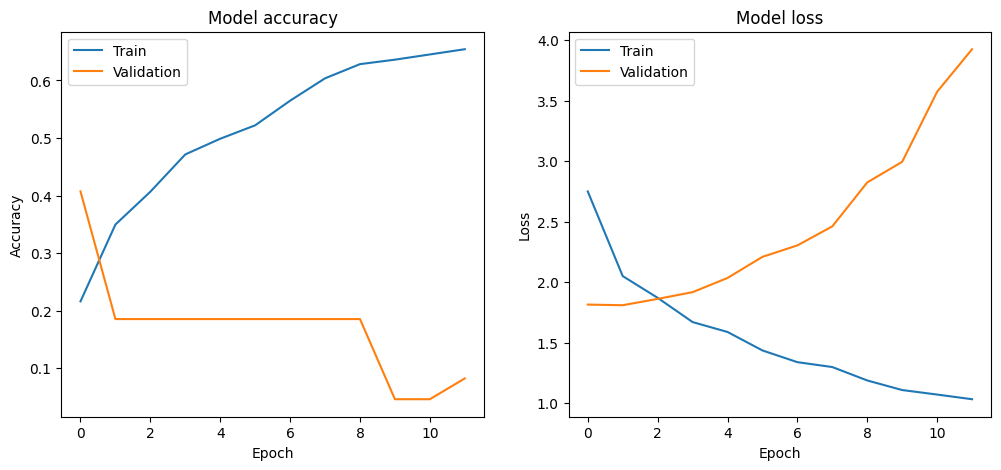

In [11]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

## 8. Evaluating the Model

After training, we evaluate the model's performance on the unseen test set using various metrics such as accuracy, precision, recall, F1-score, and a confusion matrix. A classification report provides a summary of these metrics for each class.

In [12]:
# Evaluate the model on the test data
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Get predictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=target_names))

Test Loss: 1.7997
Test Accuracy: 0.1832
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step

Classification Report:
                   precision    recall  f1-score   support

     Ariel Sharon       0.00      0.00      0.00        19
     Colin Powell       0.18      1.00      0.31        59
  Donald Rumsfeld       0.00      0.00      0.00        30
    George W Bush       0.00      0.00      0.00       133
Gerhard Schroeder       0.00      0.00      0.00        27
      Hugo Chavez       0.00      0.00      0.00        18
       Tony Blair       0.00      0.00      0.00        36

         accuracy                           0.18       322
        macro avg       0.03      0.14      0.04       322
     weighted avg       0.03      0.18      0.06       322



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


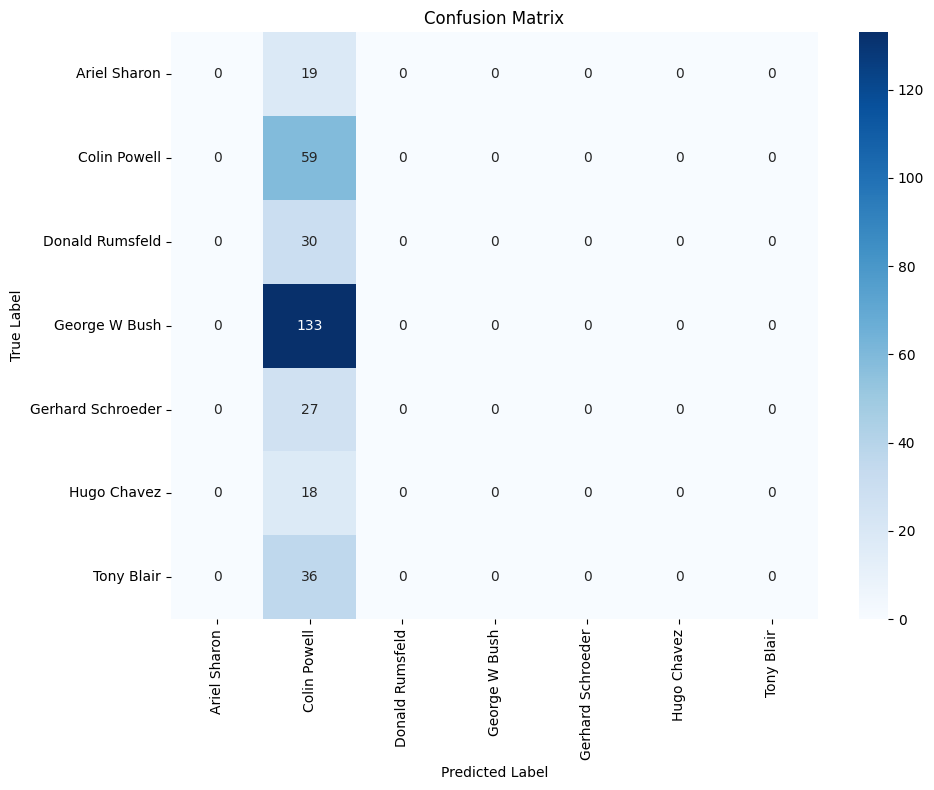

In [13]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 9. Displaying Sample Predictions

Let's visualize some test images along with their actual and predicted labels to get a qualitative understanding of the model's performance.

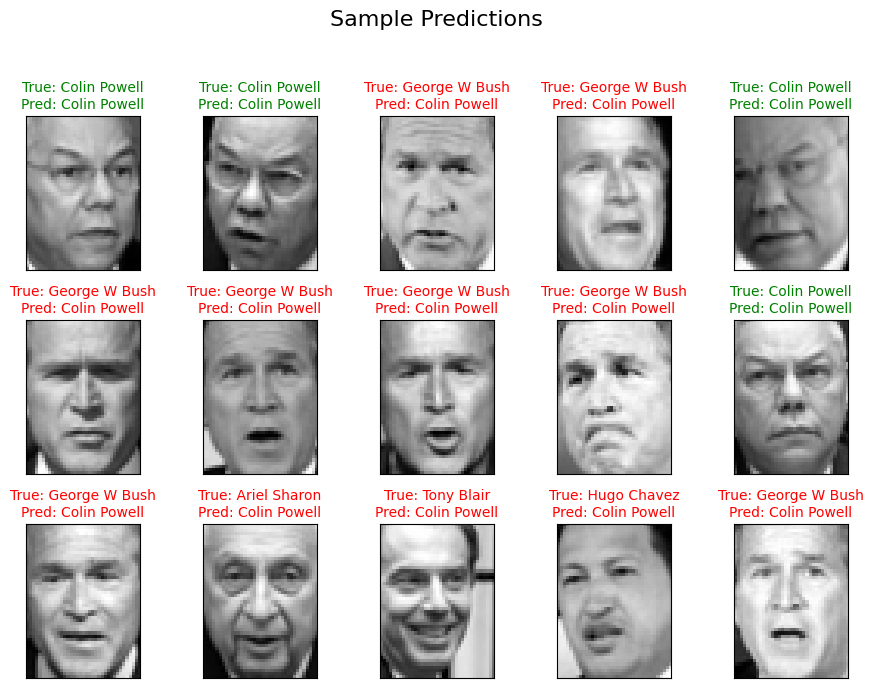

In [14]:
# Function to plot sample predictions
def plot_predictions(images, true_labels, predicted_labels, n_row=2, n_col=5):
    plt.figure(figsize=(1.8 * n_col, 2.4 * n_row))
    plt.suptitle("Sample Predictions", size=16)
    for i in range(n_row * n_col):
        plt.subplot(n_row, n_col, i + 1)
        plt.imshow(images[i].reshape((h, w)), cmap='gray')
        true_name = target_names[true_labels[i]]
        pred_name = target_names[predicted_labels[i]]
        color = 'green' if true_name == pred_name else 'red'
        plt.title(f"True: {true_name}\nPred: {pred_name}", color=color, size=10)
        plt.xticks(())
        plt.yticks(())
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Plot sample predictions
plot_predictions(X_test, y_true, y_pred, n_row=3, n_col=5)

## 10. Saving and Loading the Trained Model

Once the model is trained, it's crucial to save it for future use without needing to retrain. Keras provides simple functions to save and load models.

In [15]:
# Define a file path for the model
model_save_path = 'face_recognition_cnn_model.keras'

# Save the trained model
model.save(model_save_path)
print(f"Model saved successfully to {model_save_path}")

Model saved successfully to face_recognition_cnn_model.keras


In [16]:
# Load the saved model
loaded_model = load_model(model_save_path)
loaded_model.summary()

# Verify the loaded model's performance
loss_loaded, accuracy_loaded = loaded_model.evaluate(X_test, y_test, verbose=0)
print(f"\nLoaded Model Test Loss: {loss_loaded:.4f}")
print(f"Loaded Model Test Accuracy: {accuracy_loaded:.4f}")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 35, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 35, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 17, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 17, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 22, 15, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 22, 15, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 11, 7, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 11, 7, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 9, 5, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 9, 5, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,074,455 (4.10 MB)

 Trainable params: 357,831 (1.37 MB)

 Non-trainable params: 960 (3.75 KB)

 Optimizer params: 715,664 (2.73 MB)


Loaded Model Test Loss: 1.7997
Loaded Model Test Accuracy: 0.1832


## 11. Predicting the Identity of a New Face Image

Finally, let's demonstrate how to use the trained model to predict the identity of a new, unseen face image from the LFW dataset. We'll pick a random image from the test set.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step


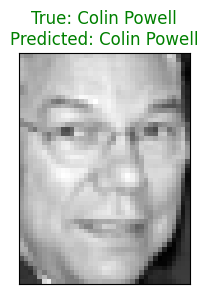

Actual Identity: Colin Powell
Predicted Identity: Colin Powell
Confidence: 27.69%


In [17]:
# Pick a random image from the test set for prediction
random_idx = np.random.randint(0, len(X_test))
sample_image = X_test[random_idx]
sample_true_label_idx = y_true[random_idx]

# Reshape the image to be (1, height, width, channels) for prediction
sample_image_input = np.expand_dims(sample_image, axis=0)

# Make a prediction
prediction_probs = loaded_model.predict(sample_image_input)
predicted_label_idx = np.argmax(prediction_probs)

# Get the names
true_name = target_names[sample_true_label_idx]
predicted_name = target_names[predicted_label_idx]

# Display the image and prediction
plt.figure(figsize=(3, 3))
plt.imshow(sample_image.reshape((h, w)), cmap='gray')
plt.title(f"True: {true_name}\nPredicted: {predicted_name}",
          color='green' if true_name == predicted_name else 'red')
plt.xticks(())
plt.yticks(())
plt.show()

print(f"Actual Identity: {true_name}")
print(f"Predicted Identity: {predicted_name}")
print(f"Confidence: {np.max(prediction_probs) * 100:.2f}%")